<a href="https://colab.research.google.com/github/Aldritch001/cropguard-ai/blob/main/02_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CropGuard AI - Data Exploration
Author: Absolon

Before training anything I wanted to actually understand the dataset I'm working with. PlantVillage has over 54,000 labelled images across 38 classes of healthy and diseased crop leaves. This notebook downloads it, checks how balanced the classes are, looks at real sample images, and builds a proper train, validation and test split for the model in the next stage.

Setting up the Kaggle API so I can pull the dataset directly into Colab instead of uploading it manually.

In [1]:
!pip install -q kaggle

from google.colab import files
import os

uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
os.system("cp kaggle.json /root/.kaggle/kaggle.json")
os.system("chmod 600 /root/.kaggle/kaggle.json")

Saving kaggle.json to kaggle.json


0

Downloading the PlantVillage dataset and extracting it.

In [2]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

import zipfile

with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage_data")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:28<00:00, 75.8MB/s]



Checking the folder structure first. The dataset is organised as one folder per class, named as crop and condition, for example Tomato___Late_blight.

In [3]:
import os

base_dir = "plantvillage_data"

for root, dirs, files_in_dir in os.walk(base_dir):
    level = root.replace(base_dir, "").count(os.sep)
    if level < 2:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        break

plantvillage_data/
  plantvillage dataset/


Finding the actual root folder that holds all the class subfolders, then listing every class.

In [4]:
import os

def find_dataset_root(base_dir):
    for root, dirs, files_in_dir in os.walk(base_dir):
        if len(dirs) >= 10:
            return root
    return None

DATA_DIR = find_dataset_root(base_dir)
print(f"Dataset root: {DATA_DIR}")

class_names = sorted(os.listdir(DATA_DIR))
print(f"Total classes: {len(class_names)}")
for name in class_names[:10]:
    print(f"  {name}")

Dataset root: plantvillage_data/plantvillage dataset/color
Total classes: 38
  Apple___Apple_scab
  Apple___Black_rot
  Apple___Cedar_apple_rust
  Apple___healthy
  Blueberry___healthy
  Cherry_(including_sour)___Powdery_mildew
  Cherry_(including_sour)___healthy
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  Corn_(maize)___Common_rust_
  Corn_(maize)___Northern_Leaf_Blight


Counting images per class. Some diseases have far more photos than others in this dataset, which matters because a model trained on imbalanced data tends to get lazy and just favours whichever class has the most examples.

In [5]:
import pandas as pd

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["class_name", "image_count"]
).sort_values("image_count", ascending=False)

print(f"Total images: {df_counts['image_count'].sum()}")
print(f"Average per class: {df_counts['image_count'].mean():.0f}")
print(f"Smallest class: {df_counts.iloc[-1]['class_name']} with {df_counts.iloc[-1]['image_count']} images")
print(f"Largest class: {df_counts.iloc[0]['class_name']} with {df_counts.iloc[0]['image_count']} images")
df_counts

Total images: 54305
Average per class: 1429
Smallest class: Potato___healthy with 152 images
Largest class: Orange___Haunglongbing_(Citrus_greening) with 5507 images


,class_name,image_count
15,Orange___Haunglongbing_(Citrus_greening),5507
35,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
24,Soybean___healthy,5090
16,Peach___Bacterial_spot,2297
28,Tomato___Bacterial_spot,2127
30,Tomato___Late_blight,1909
25,Squash___Powdery_mildew,1835
32,Tomato___Septoria_leaf_spot,1771
33,Tomato___Spider_mites Two-spotted_spider_mite,1676
3,Apple___healthy,1645


Plotting the distribution to see the imbalance more clearly than the table shows.

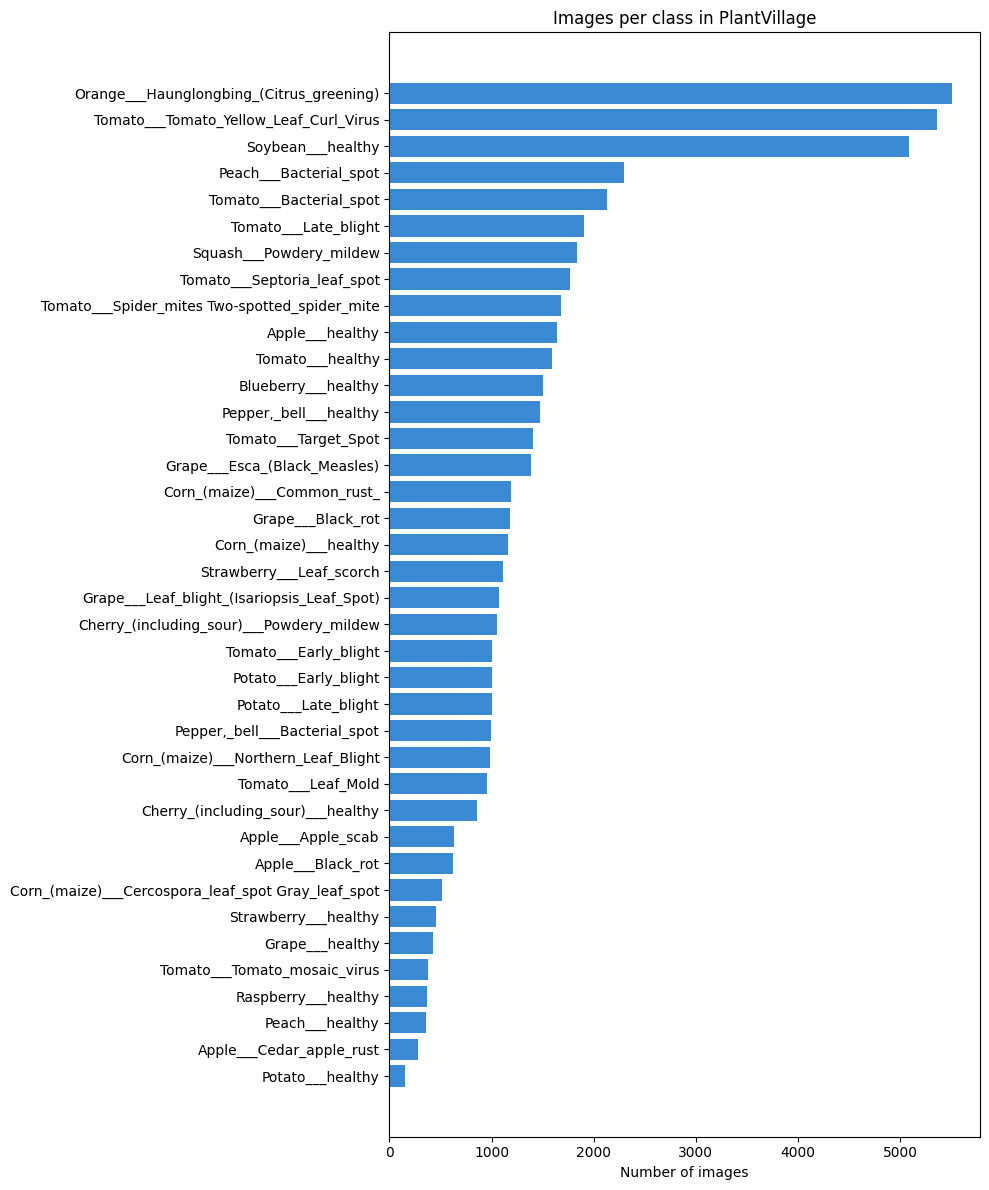

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plt.barh(df_counts["class_name"], df_counts["image_count"], color="#3B8BD4")
plt.xlabel("Number of images")
plt.title("Images per class in PlantVillage")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

For version one I'm narrowing this down to five crops that matter most for smallholder farmers in Southern Africa. The original PlantVillage set doesn't actually include Wheat or Cassava, so the five I'm going with based on what's genuinely available with strong sample counts are Tomato, Potato, Pepper, Corn and Grape. Tomato and Potato diseases alone cover a huge amount of real farming pain, so this is still a solid starting point. I can expand to more crops once the first model is working.

In [7]:
target_crops = ["Tomato", "Potato", "Pepper", "Corn", "Grape"]

target_classes = [
    name for name in class_names
    if any(crop.lower() in name.lower() for crop in target_crops)
]

print(f"Classes matching target crops: {len(target_classes)}")
for name in target_classes:
    print(f"  {name}  ({class_counts[name]} images)")

Classes matching target crops: 23
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot  (513 images)
  Corn_(maize)___Common_rust_  (1192 images)
  Corn_(maize)___Northern_Leaf_Blight  (985 images)
  Corn_(maize)___healthy  (1162 images)
  Grape___Black_rot  (1180 images)
  Grape___Esca_(Black_Measles)  (1383 images)
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)  (1076 images)
  Grape___healthy  (423 images)
  Pepper,_bell___Bacterial_spot  (997 images)
  Pepper,_bell___healthy  (1478 images)
  Potato___Early_blight  (1000 images)
  Potato___Late_blight  (1000 images)
  Potato___healthy  (152 images)
  Tomato___Bacterial_spot  (2127 images)
  Tomato___Early_blight  (1000 images)
  Tomato___Late_blight  (1909 images)
  Tomato___Leaf_Mold  (952 images)
  Tomato___Septoria_leaf_spot  (1771 images)
  Tomato___Spider_mites Two-spotted_spider_mite  (1676 images)
  Tomato___Target_Spot  (1404 images)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus  (5357 images)
  Tomato___Tomato_mosaic_virus  (373 i

Wanted to actually look at real examples rather than just trust the folder names, so pulling a random sample from a few classes.

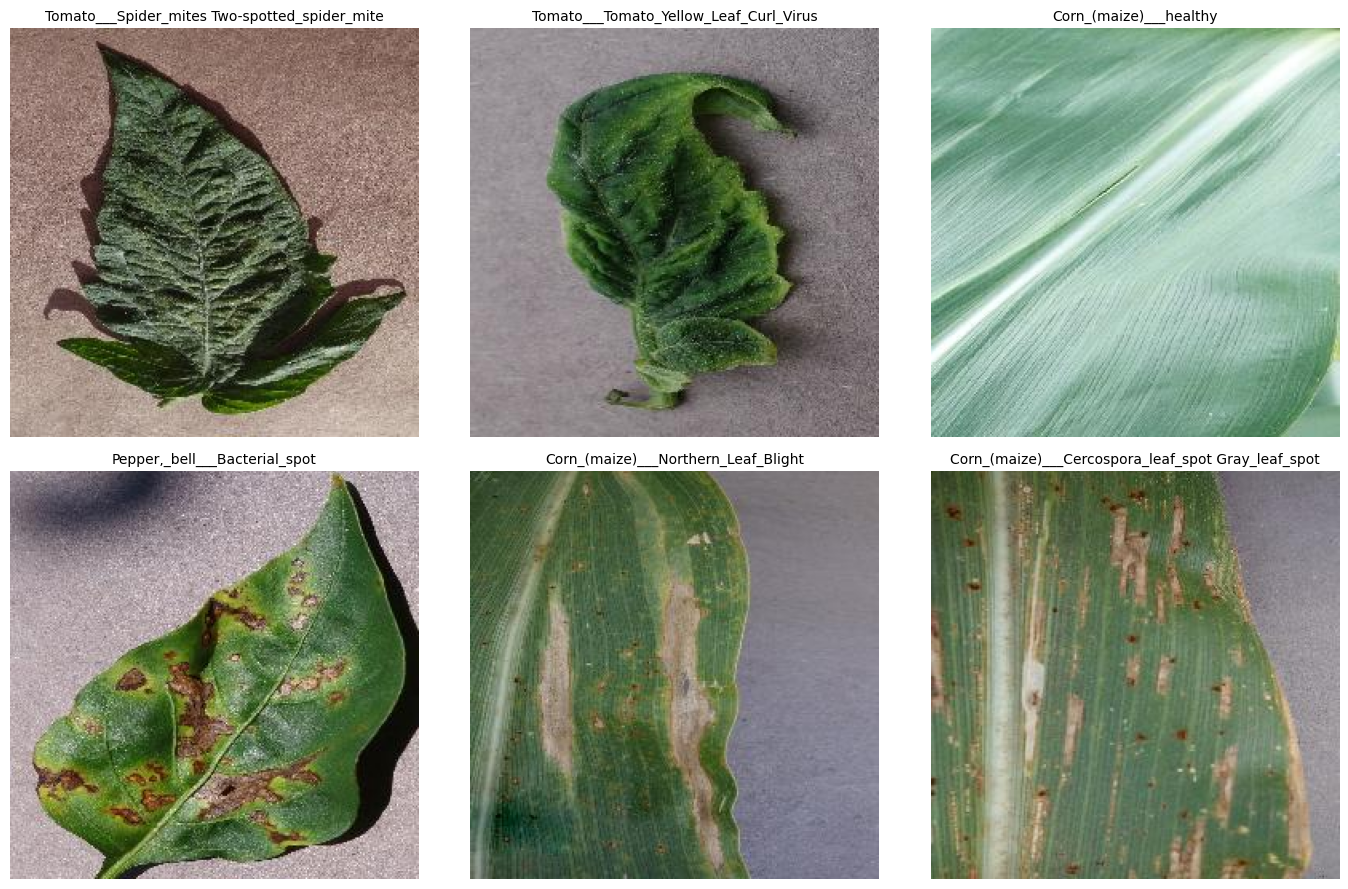

In [8]:
from PIL import Image
import random
import matplotlib.pyplot as plt

sample_classes = random.sample(target_classes, min(6, len(target_classes)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, class_name in enumerate(sample_classes):
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = os.listdir(class_path)
    sample_image_path = os.path.join(class_path, random.choice(image_files))

    img = Image.open(sample_image_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Checking if images come in consistent sizes. They don't, which is expected, so every image will get resized to a fixed dimension before training, same approach as the preprocessing step I built earlier.

In [9]:
from PIL import Image
import os
import random

sizes = set()

for class_name in target_classes[:5]:
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = os.listdir(class_path)
    sample_files = random.sample(image_files, min(5, len(image_files)))
    for file_name in sample_files:
        img = Image.open(os.path.join(class_path, file_name))
        sizes.add(img.size)

print("Image sizes found in sample:")
for size in sizes:
    print(f"  {size}")

Image sizes found in sample:
  (256, 256)


Splitting into train, validation and test sets. Train is what the model learns from, validation is what I check progress against while training, and test is held back completely so I get an honest read on performance at the end. Going with a 70/15/15 split.

In [10]:
import os
import shutil
import random

random.seed(42)

SPLIT_DIR = "cropguard_split"
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

for split in ["train", "val", "test"]:
    for class_name in target_classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, class_name), exist_ok=True)

for class_name in target_classes:
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = os.listdir(class_path)
    random.shuffle(image_files)

    n_total = len(image_files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)

    train_files = image_files[:n_train]
    val_files = image_files[n_train:n_train + n_val]
    test_files = image_files[n_train + n_val:]

    for file_name in train_files:
        shutil.copy(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "train", class_name, file_name)
        )
    for file_name in val_files:
        shutil.copy(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "val", class_name, file_name)
        )
    for file_name in test_files:
        shutil.copy(
            os.path.join(class_path, file_name),
            os.path.join(SPLIT_DIR, "test", class_name, file_name)
        )

    print(f"{class_name}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test")

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 359 train, 76 val, 78 test
Corn_(maize)___Common_rust_: 834 train, 178 val, 180 test
Corn_(maize)___Northern_Leaf_Blight: 689 train, 147 val, 149 test
Corn_(maize)___healthy: 813 train, 174 val, 175 test
Grape___Black_rot: 826 train, 177 val, 177 test
Grape___Esca_(Black_Measles): 968 train, 207 val, 208 test
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 753 train, 161 val, 162 test
Grape___healthy: 296 train, 63 val, 64 test
Pepper,_bell___Bacterial_spot: 697 train, 149 val, 151 test
Pepper,_bell___healthy: 1034 train, 221 val, 223 test
Potato___Early_blight: 700 train, 150 val, 150 test
Potato___Late_blight: 700 train, 150 val, 150 test
Potato___healthy: 106 train, 22 val, 24 test
Tomato___Bacterial_spot: 1488 train, 319 val, 320 test
Tomato___Early_blight: 700 train, 150 val, 150 test
Tomato___Late_blight: 1336 train, 286 val, 287 test
Tomato___Leaf_Mold: 666 train, 142 val, 144 test
Tomato___Septoria_leaf_spot: 1239 train, 265 val, 

Colab wipes everything when the session ends, so I want a copy of this split saved somewhere permanent. Rather than mounting Google Drive, which asks for pretty broad account access I'd rather not grant, I'm just zipping the split and downloading it straight to my computer. I can re-upload it next time instead of redoing the download and split from scratch.


In [13]:
import shutil
from google.colab import files

shutil.make_archive("cropguard_split", "zip", SPLIT_DIR)

print("Zipped the split, starting download")
files.download("cropguard_split.zip")

Zipped the split, starting download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset is downloaded, explored, filtered to the five target crops, and split cleanly into train, validation and test sets saved to Drive. Next step is training an actual model on this using transfer learning.